<a href="https://colab.research.google.com/github/jingxuchen19/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Class%2014/Lab_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ingestion and Naive Baseline Model
url = 'https://raw.githubusercontent.com/jingxuchen19/ECON5200-Applied-Data-Analytics-in-Economics/refs/heads/main/Data/Nvidia_AI_Capex_Diagnostics_2026.csv'
df = pd.read_csv(url)

formula = 'AI_Software_Revenue ~ Hardware_Capex + Data_Center_Power_MW + Cloud_GPU_Deployments'
baseline_model = smf.ols(formula, data=df).fit()

print("--- NAIVE BASELINE OLS MODEL ---")
print(baseline_model.summary())

--- NAIVE BASELINE OLS MODEL ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     2831.
Date:                 Tue, 17 Mar 2026   Prob (F-statistic):          2.35e-190
Time:                         17:58:28   Log-Likelihood:                -1409.7
No. Observations:                  250   AIC:                             2827.
Df Residuals:                      246   BIC:                             2841.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

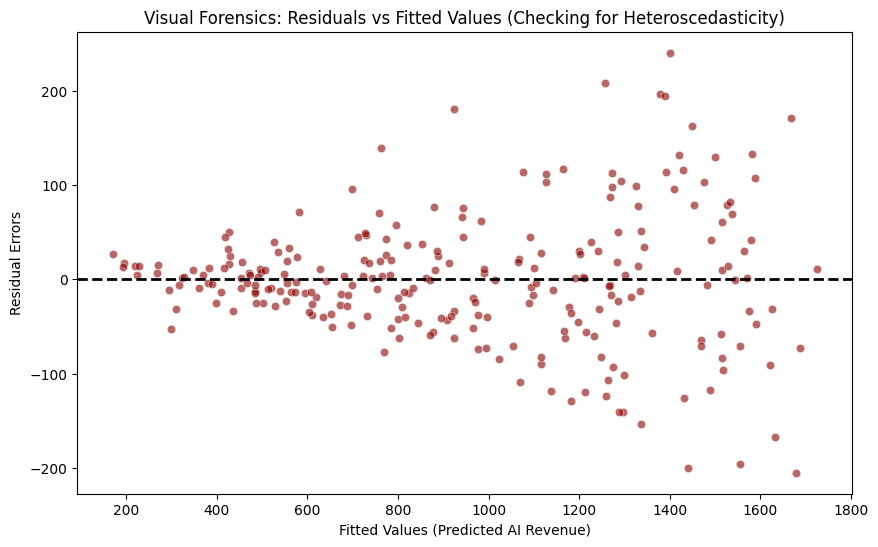

In [5]:
# Step 2: Visual Forensics
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6, color='darkred')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Visual Forensics: Residuals vs Fitted Values (Checking for Heteroscedasticity)')
plt.xlabel('Fitted Values (Predicted AI Revenue)')
plt.ylabel('Residual Errors')
plt.show()

In [9]:
# Step 3: The White Test Execution
# We must extract the design matrix generated by the formula interface
exog_matrix = baseline_model.model.exog

white_test_results = het_white(baseline_model.resid, exog_matrix)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("\n--- WHITE TEST RESULTS ---")
print(dict(zip(labels, white_test_results)))


--- WHITE TEST RESULTS ---
{'LM Statistic': np.float64(57.28455303762414), 'LM-Test p-value': np.float64(4.457532669743847e-09), 'F-Statistic': np.float64(7.92665095134561), 'F-Test p-value': np.float64(3.021961826065754e-10)}


In [10]:
# Step 4: Variance Inflation Factor (VIF) Loop
print("\n--- VARIANCE INFLATION FACTORS ---")

# Start loop at 1 to skip the constant intercept column at index 0
for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)
    print(dict(zip(labels, [f"{x:.2f}" for x in white_test_results])))


--- VARIANCE INFLATION FACTORS ---
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}


In [11]:
# Step 5: The Correction - HC3 Robust Standard Errors
robust_model = smf.ols('AI_Software_Revenue ~ Hardware_Capex + Cloud_GPU_Deployments', data=df).fit(cov_type='HC3')

print("\n--- ROBUST OLS MODEL (HC3) ---")
print(robust_model.summary())


--- ROBUST OLS MODEL (HC3) ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     3555.
Date:                 Tue, 17 Mar 2026   Prob (F-statistic):          9.05e-183
Time:                         18:14:54   Log-Likelihood:                -1409.9
No. Observations:                  250   AIC:                             2826.
Df Residuals:                      247   BIC:                             2836.
Df Model:                            2                                         
Covariance Type:                   HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [13]:
# AI-Assisted Expansion: Interactive Diagnostic Dashboard
!pip -q install plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Panel 1: Residual Scatter Plot with Outlier Highlighting ---
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid
resid_std = residuals.std()

# Label outliers that exceed 2 standard deviations
colors = ["Outlier" if abs(r) > 2 * resid_std else "Normal" for r in residuals]

fig1 = px.scatter(
    x=fitted_vals, y=residuals, color=colors,
    color_discrete_map={"Normal": "steelblue", "Outlier": "crimson"},
    labels={"x": "Fitted Values (Predicted Revenue)", "y": "Residual Errors", "color": "Category"},
    title="Residual Forensics: Naive OLS Residuals vs Fitted Values"
)
fig1.add_hline(y=0, line_dash="dash", line_color="black")
fig1.show()

# --- Panel 2: Naive vs Robust Coefficient Comparison ---
naive_params = baseline_model.params[1:]
naive_se = baseline_model.bse[1:]
robust_params = robust_model.params[1:]
robust_se = robust_model.bse[1:]

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    name="Naive OLS",
    x=naive_params.index.tolist(),
    y=naive_params.values,
    error_y=dict(type="data", array=naive_se.values * 1.96),
    marker_color="steelblue"
))
fig2.add_trace(go.Bar(
    name="Robust HC3",
    x=robust_params.index.tolist(),
    y=robust_params.values,
    error_y=dict(type="data", array=robust_se.values * 1.96),
    marker_color="crimson"
))
fig2.update_layout(
    title="Coefficient Comparison: Naive OLS vs HC3 Robust (with 95% CI)",
    barmode="group",
    xaxis_title="Variable",
    yaxis_title="Coefficient Value"
)
fig2.show()

# --- Panel 3: VIF Scores ---
vif_data = []
exog = baseline_model.model.exog
exog_names = baseline_model.model.exog_names
for i in range(1, exog.shape[1]):
    vif_data.append({
        "Variable": exog_names[i],
        "VIF": round(variance_inflation_factor(exog, i), 2)
    })
vif_df = pd.DataFrame(vif_data)

fig3 = px.bar(
    vif_df, x="Variable", y="VIF",
    title="Variance Inflation Factors (VIF > 10 = Severe Multicollinearity)",
    color="VIF",
    color_continuous_scale=["steelblue", "crimson"]
)
fig3.add_hline(y=10, line_dash="dash", line_color="red", annotation_text="VIF = 10 Threshold")
fig3.show()

# --- Panel 4: White Test Summary ---
print("\n--- DIAGNOSTIC SUMMARY ---")
print(f"White Test p-value: {white_test_results[1]:.6f}")
if white_test_results[1] < 0.05:
    print("Result: Heteroscedasticity CONFIRMED. HC3 correction is necessary.")
else:
    print("Result: No significant heteroscedasticity detected.")


--- DIAGNOSTIC SUMMARY ---
White Test p-value: 0.000000
Result: Heteroscedasticity CONFIRMED. HC3 correction is necessary.
